In [3]:
import pandas as pd
import numpy as np

# Load the dataset
data = pd.read_csv('/content/Task 3 and 4_Loan_Data.csv')

# Prepare data for quantization (FICO scores and default status)
# Assuming columns are named 'fico_score' and 'default'
fico = data['fico_score'].values
defaults = data['default'].values

# Sort data by FICO score for easier bucket processing
idx = np.argsort(fico)
fico = fico[idx]
defaults = defaults[idx]

display(data.head())

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


### Log-Likelihood Optimization via Dynamic Programming

Kita akan mencari batas bucket $b_i$ yang memaksimalkan:
$$\text{Likelihood} = \sum_{i=1}^{n} [k_i \ln(p_i) + (n_i - k_i) \ln(1 - p_i)]$$
dimana:
- $n_i$ = jumlah record di bucket $i$
- $k_i$ = jumlah default di bucket $i$
- $p_i = k_i / n_i$

In [4]:
def log_likelihood(n, k):
    if n == 0 or k == 0 or k == n:
        return 0
    p = k / n
    return k * np.log(p) + (n - k) * np.log(1 - p)

def optimize_buckets(fico, defaults, num_buckets):
    # Group unique FICO scores to reduce DP complexity
    unique_ficos, indices = np.unique(fico, return_inverse=True)
    n_unique = len(unique_ficos)

    # Precompute n and k for all possible contiguous segments
    counts = np.bincount(indices)
    default_counts = np.bincount(indices, weights=defaults)

    # DP Table
    # dp[i][j] is max likelihood using i buckets for first j unique FICO values
    dp = np.full((num_buckets + 1, n_unique + 1), -np.inf)
    backtrack = np.zeros((num_buckets + 1, n_unique + 1), dtype=int)

    # Base case: 1 bucket
    current_n = 0
    current_k = 0
    for j in range(1, n_unique + 1):
        current_n += counts[j-1]
        current_k += default_counts[j-1]
        dp[1][j] = log_likelihood(current_n, current_k)

    # Fill DP table
    for i in range(2, num_buckets + 1):
        for j in range(i, n_unique + 1):
            current_n = 0
            current_k = 0
            for m in range(j, i - 1, -1):
                current_n += counts[m-1]
                current_k += default_counts[m-1]
                val = dp[i-1][m-1] + log_likelihood(current_n, current_k)
                if val > dp[i][j]:
                    dp[i][j] = val
                    backtrack[i][j] = m - 1

    # Recover boundaries
    boundaries = []
    curr_j = n_unique
    for i in range(num_buckets, 1, -1):
        split_idx = backtrack[i][curr_j]
        boundaries.append(unique_ficos[split_idx])
        curr_j = split_idx

    return sorted(boundaries)

# Example: Create 10 buckets
buckets = optimize_buckets(fico, defaults, 10)
print(f"Optimized FICO Boundaries: {buckets}")

Optimized FICO Boundaries: [np.int64(521), np.int64(553), np.int64(581), np.int64(612), np.int64(650), np.int64(697), np.int64(733), np.int64(753), np.int64(754)]


In [5]:
def map_to_rating(score, boundaries):
    # Lower rating = better credit score
    # We use boundaries to define the buckets
    for i, b in enumerate(boundaries):
        if score <= b:
            return i + 1
    return len(boundaries) + 1

# Apply the rating map to the dataset
data['rating'] = data['fico_score'].apply(lambda x: map_to_rating(x, buckets))

# Display the results with the new ratings
print("Sample of FICO scores and their assigned ratings:")
display(data[['fico_score', 'rating', 'default']].head(10))

# Validate the rating by showing the default rate per rating
rating_summary = data.groupby('rating')['default'].agg(['count', 'sum', 'mean'])
rating_summary.columns = ['Total Records', 'Defaults', 'Default Rate']
display(rating_summary)

Sample of FICO scores and their assigned ratings:


,fico_score,rating,default
0,605,4,0
1,572,3,1
2,602,4,0
3,612,4,0
4,631,5,0
5,697,6,0
6,722,7,0
7,545,2,1
8,676,6,0
9,447,1,0


,Total Records,Defaults,Default Rate
rating,,,
1,316,206,0.651899
2,500,227,0.454000
3,945,312,0.330159
4,1581,382,0.241619
5,2465,398,0.161460
6,2591,250,0.096488
7,1069,63,0.058934
8,291,8,0.027491
9,5,0,0.000000


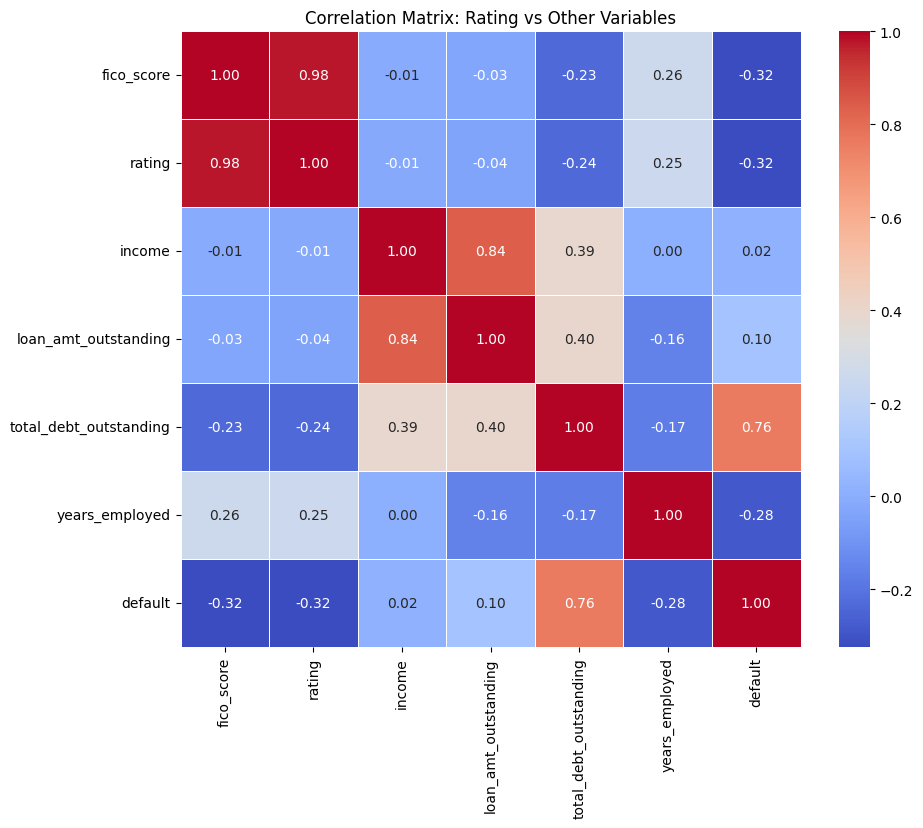

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Memilih kolom numerik untuk analisis korelasi
cols_to_analyze = ['fico_score', 'rating', 'income', 'loan_amt_outstanding', 'total_debt_outstanding', 'years_employed', 'default']
correlation_matrix = data[cols_to_analyze].corr()

# Visualisasi Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: Rating vs Other Variables')
plt.show()

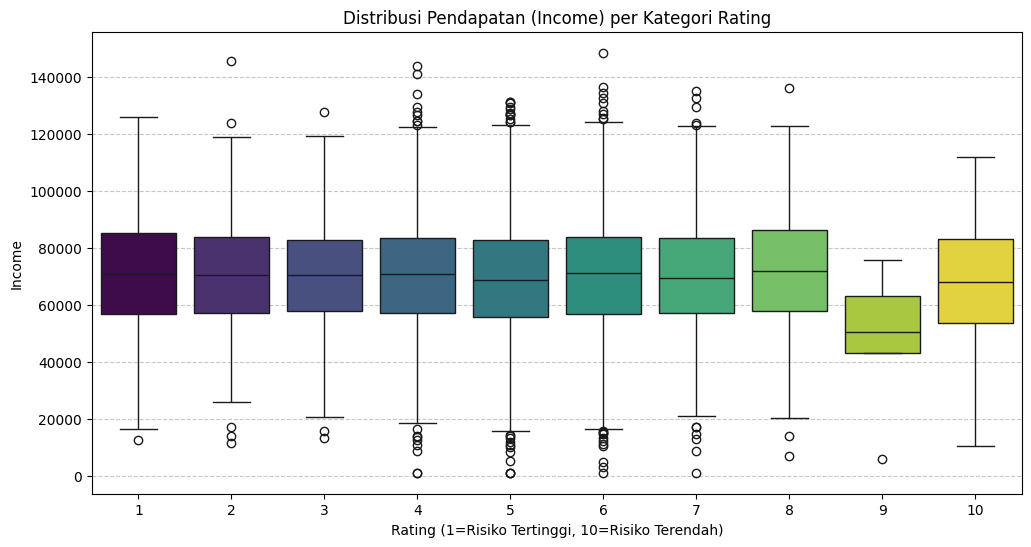

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
# Menambahkan hue='rating' dan legend=False untuk memperbaiki FutureWarning
sns.boxplot(x='rating', y='income', data=data, palette='viridis', hue='rating', legend=False)

plt.title('Distribusi Pendapatan (Income) per Kategori Rating')
plt.xlabel('Rating (1=Risiko Tertinggi, 10=Risiko Terendah)')
plt.ylabel('Income')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

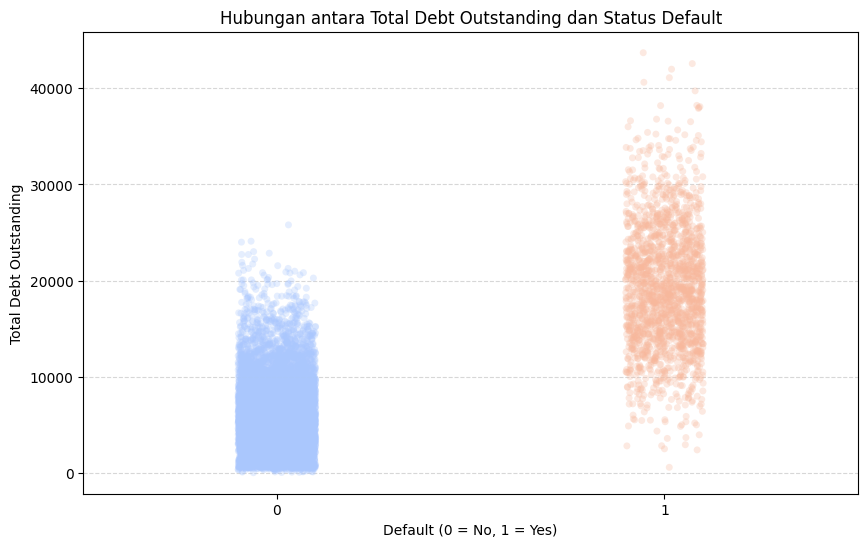

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Menggunakan stripplot agar titik-titik tidak saling menumpuk (jitter)
sns.stripplot(x='default', y='total_debt_outstanding', data=data, alpha=0.3, jitter=True, palette='coolwarm', hue='default', legend=False)

plt.title('Hubungan antara Total Debt Outstanding dan Status Default')
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.ylabel('Total Debt Outstanding')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

--- Model Evaluation (Predicting Default using Rating) ---
Accuracy Score: 0.8245

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90      1630
           1       0.69      0.09      0.16       370

    accuracy                           0.82      2000
   macro avg       0.76      0.54      0.53      2000
weighted avg       0.80      0.82      0.77      2000



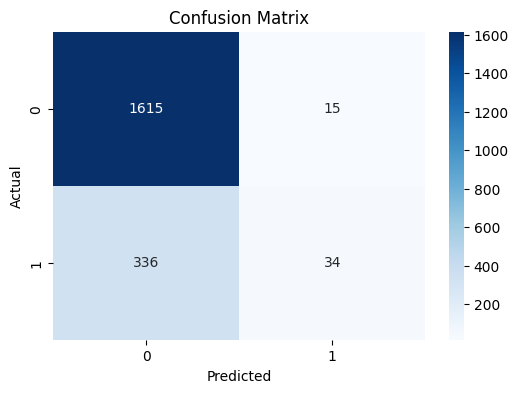

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Menyiapkan fitur (X) dan target (y)
# Kita menggunakan 'rating' sebagai prediktor utama
X = data[['rating']]
y = data['default']

# Membagi data menjadi training (80%) dan testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Inisialisasi dan latih model
model = LogisticRegression()
model.fit(X_train, y_train)

# Melakukan prediksi pada data testing
y_pred = model.predict(X_test)

# Evaluasi Model
print("--- Model Evaluation (Predicting Default using Rating) ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

--- Model Evaluation (Rating + Total Debt Outstanding) ---
Accuracy Score: 0.9340

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1630
           1       0.85      0.78      0.81       370

    accuracy                           0.93      2000
   macro avg       0.90      0.87      0.89      2000
weighted avg       0.93      0.93      0.93      2000



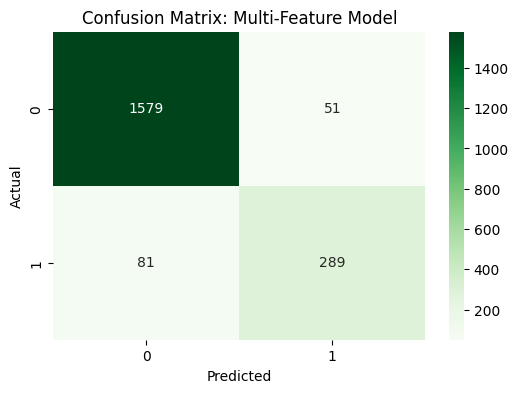

In [11]:
from sklearn.preprocessing import StandardScaler

# Menyiapkan fitur (X) dengan menambahkan 'total_debt_outstanding'
X_multi = data[['rating', 'total_debt_outstanding']]
y = data['default']

# Membagi data (stratified split)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42, stratify=y)

# Scaling sangat penting untuk Logistic Regression jika rentang nilai fitur berbeda jauh
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_m)
X_test_scaled = scaler.transform(X_test_m)

# Melatih model baru
model_multi = LogisticRegression()
model_multi.fit(X_train_scaled, y_train_m)

# Prediksi
y_pred_multi = model_multi.predict(X_test_scaled)

# Evaluasi
print("--- Model Evaluation (Rating + Total Debt Outstanding) ---")
print(f"Accuracy Score: {accuracy_score(y_test_m, y_pred_multi):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_m, y_pred_multi))

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_m, y_pred_multi), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix: Multi-Feature Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

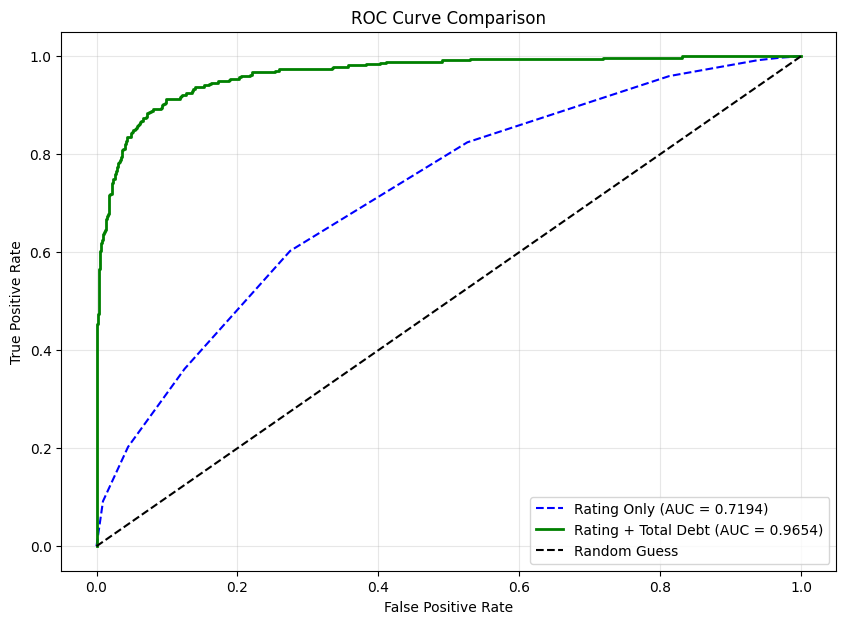

Peningkatan AUC: 0.2459


In [12]:
from sklearn.metrics import roc_curve, roc_auc_score

# Menghitung probabilitas prediksi untuk kedua model
y_prob_single = model.predict_proba(X_test)[:, 1]
y_prob_multi = model_multi.predict_proba(X_test_scaled)[:, 1]

# Menghitung ROC curve
fpr_s, tpr_s, _ = roc_curve(y_test, y_prob_single)
fpr_m, tpr_m, _ = roc_curve(y_test_m, y_prob_multi)

# Menghitung AUC
auc_single = roc_auc_score(y_test, y_prob_single)
auc_multi = roc_auc_score(y_test_m, y_prob_multi)

# Plotting
plt.figure(figsize=(10, 7))
plt.plot(fpr_s, tpr_s, label=f'Rating Only (AUC = {auc_single:.4f})', color='blue', linestyle='--')
plt.plot(fpr_m, tpr_m, label=f'Rating + Total Debt (AUC = {auc_multi:.4f})', color='green', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"Peningkatan AUC: {auc_multi - auc_single:.4f}")

### Analisis Scatter/Strip Plot:
- Terlihat perbedaan yang jelas pada distribusi utang. Peminjam yang mengalami **default (1)** cenderung memiliki konsentrasi utang yang jauh lebih tinggi dibandingkan mereka yang tidak default.
- Hal ini menjelaskan mengapa korelasi antara kedua variabel ini mencapai angka yang signifikan (~0.76).

### Observasi Distribusi Pendapatan:
- Jika kotak (*box*) berada di level yang serupa di semua rating, ini mengonfirmasi temuan korelasi sebelumnya bahwa pendapatan tidak menjadi faktor penentu utama dalam penetapan skor FICO/Rating dalam dataset ini.
- Kita bisa melihat apakah ada tren tertentu, misalnya apakah orang dengan rating lebih baik (rating tinggi) cenderung memiliki variasi pendapatan yang lebih kecil atau lebih besar.

### Analisis Hasil Korelasi:
- **Rating vs FICO Score**: Seharusnya memiliki korelasi negatif yang sangat kuat karena rating rendah diberikan untuk skor FICO yang tinggi.
- **Rating vs Default**: Membantu memvalidasi apakah rating yang lebih tinggi (risiko lebih besar) berkorelasi positif dengan kejadian default.
- **Rating vs Income/Debt**: Melihat apakah kapasitas keuangan peminjam berhubungan dengan rating yang dihasilkan oleh algoritma kuantisasi ini.